# 4 · What predicts a disagreement between stars and text?

The two directions of inconsistency are modelled **separately**:

* among **4–5★** reviews, what predicts *negative* text?
* among **1–2★** reviews, what predicts *positive* text?

Pooling them would average two different phenomena whose predictors can point in opposite
directions.

The notebook proceeds in four steps:

1. inconsistency rates by single factors, with no controls
2. multivariable logistic regressions, reported as odds ratios with 95% CIs. Continuous predictors
   are standardised, so an odds ratio is the effect of +1 SD.
3. a gradient-boosted model with permutation importance, which captures non-linear effects
4. the words and phrases that distinguish inconsistent from consistent reviews

**Caveat.** Text-derived predictors such as length and contrast words can also change how well the
sentiment models work (notebook 2). An association can therefore reflect true reviewer behaviour,
measurement error, or both.

In [1]:
import sys

sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from common import (BLUE, HIGH_NEG, INK_2, LOW_POS, RED, SURFACE, forest, load, rate_table,
                    ratio_table, savefig, set_style)

set_style()
df = load()
polar = df[df.polar_rating & df.avg_rating.notna()].copy()
polar["price_missing"] = polar.price.isna()
polar["log_price"] = polar.log_price.fillna(polar.log_price.median())
polar["log_user_reviews"] = np.log(polar.user_n_reviews)
polar["extreme"] = polar.rating.isin([1, 5])
GROUPS = {HIGH_NEG: polar[polar.rating >= 4].copy(), LOW_POS: polar[polar.rating <= 2].copy()}
COLOR = {HIGH_NEG: RED, LOW_POS: BLUE}
for name, g in GROUPS.items():
    print(f"{name}: {len(g):,} reviews, {g.inconsistent.mean():.2%} inconsistent")

negative text, high stars: 495,043 reviews, 1.06% inconsistent
positive text, low stars: 143,489 reviews, 4.31% inconsistent


## Single-factor views

,"negative text, high stars","positive text, low stars"
rate with vs without,,
verified_purchase,1.1% vs 0.8%,4.2% vs 5.5%
has_images,0.7% vs 1.1%,4.6% vs 4.3%
has_title,1.1% vs 0.9%,4.3% vs 4.2%
has_contrast,2.2% vs 0.7%,8.2% vs 2.8%
mentions_logistics,1.3% vs 1.0%,6.0% vs 4.2%
has_exclaim,0.5% vs 1.4%,5.3% vs 4.1%


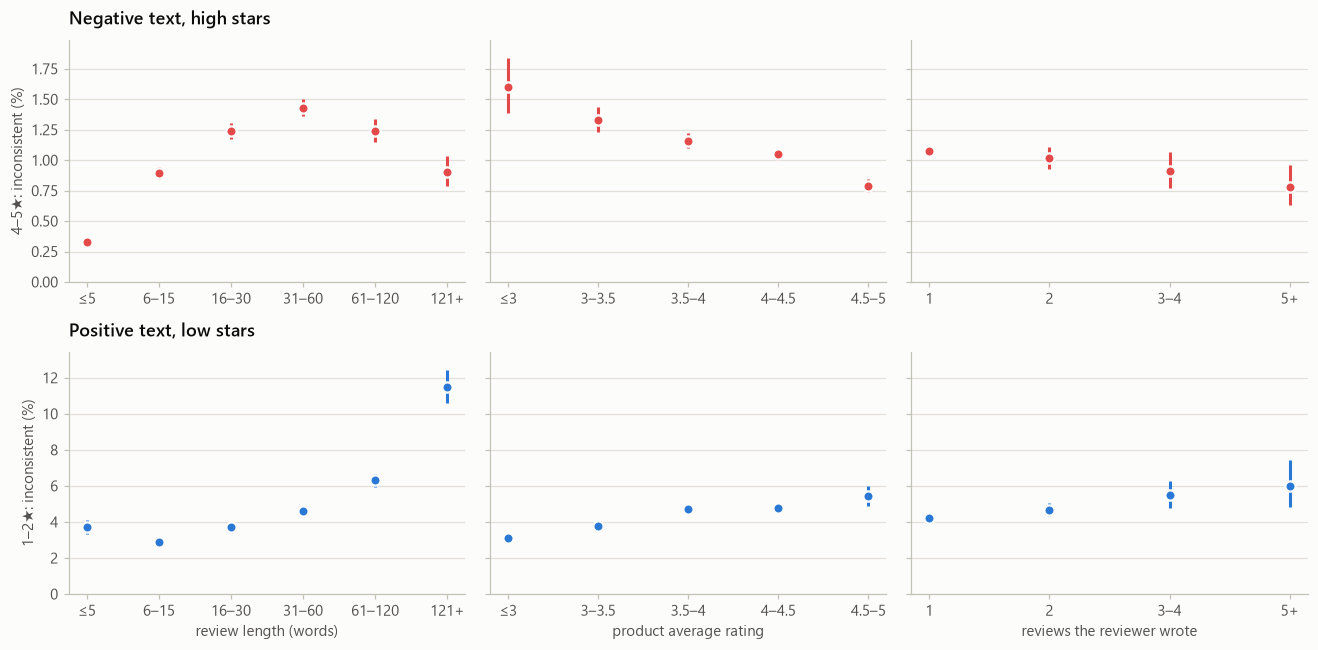

In [2]:
def binned(frame):
    return {
        "review length (words)": pd.cut(frame.word_count, [-1, 5, 15, 30, 60, 120, np.inf],
                                        labels=["≤5", "6–15", "16–30", "31–60", "61–120", "121+"]),
        "product average rating": pd.cut(frame.avg_rating, [0, 3, 3.5, 4, 4.5, 5],
                                         labels=["≤3", "3–3.5", "3.5–4", "4–4.5", "4.5–5"]),
        "reviews the reviewer wrote": pd.cut(frame.user_n_reviews, [0, 1, 2, 4, np.inf],
                                             labels=["1", "2", "3–4", "5+"]),
    }


factor_names = list(binned(polar))
fig, axes = plt.subplots(2, len(factor_names), figsize=(12, 6), sharey="row")
tables = {}
for row, (name, g) in enumerate(GROUPS.items()):
    for col, (factor, bins) in enumerate(binned(g).items()):
        t = rate_table(g.assign(_bin=bins), "_bin")
        tables[(name, factor)] = t
        ax = axes[row, col]
        x = np.arange(len(t))
        ax.vlines(x, 100 * t.lo, 100 * t.hi, color=COLOR[name], linewidth=2)
        ax.scatter(x, 100 * t.rate, color=COLOR[name], s=45, zorder=3, edgecolor=SURFACE, linewidth=1.5)
        ax.set_xticks(x, t._bin.astype(str))
        ax.grid(axis="x", visible=False)
        if row == 1:
            ax.set_xlabel(factor, color=INK_2)
        if col == 0:
            ax.set_ylabel(f"{'4–5★' if name == HIGH_NEG else '1–2★'}: inconsistent (%)")
    top = max(100 * tables[(name, f)].hi.max() for f in factor_names)
    axes[row, 0].set_ylim(0, top * 1.08)  # shared across the row
    axes[row, 0].set_title(name.capitalize(), loc="left")
fig.tight_layout()
savefig(fig, "04_single_factors")

binary = ["verified_purchase", "has_images", "has_title", "has_contrast", "mentions_logistics", "has_exclaim"]
pd.DataFrame({name: {f: f"{g.loc[g[f], 'inconsistent'].mean():.1%} vs {g.loc[~g[f], 'inconsistent'].mean():.1%}"
                     for f in binary} for name, g in GROUPS.items()}).rename_axis("rate with vs without")

## Multivariable logistic regression

negative text, high stars         \
                                                         odds_ratio     lo   
extreme rating (5★ vs 4★; 1★ vs 2★)                           0.209  0.196   
longer review (+1 SD log words)                               1.169  1.125   
user-written title                                            0.819  0.732   
includes photos                                               0.562  0.498   
verified purchase                                             1.448  1.296   
contrast word (but, however, though…)                         1.847  1.726   
mentions shipping / delivery / seller                         1.145  1.034   
exclamation mark                                              0.459  0.427   
posted later (+1 SD year)                                     1.229  1.191   
higher product avg rating (+1 SD)                             0.885  0.859   
more popular product (+1 SD log #ratings)                     1.083  1.051   
higher price (+1 SD log)                                      1.031  1.004   
price missing                                                 0.842  0.789   
more active reviewer (+1 SD log #reviews)                     0.901  0.872   

                                                         \
                                              hi      p   
extreme rating (5★ vs 4★; 1★ vs 2★)        0.222  0.000   
longer review (+1 SD log words)            1.215  0.000   
user-written title                         0.917  0.001   
includes photos                            0.633  0.000   
verified purchase                          1.617  0.000   
contrast word (but, however, though…)      1.976  0.000   
mentions shipping / delivery / seller      1.268  0.010   
exclamation mark                           0.493  0.000   
posted later (+1 SD year)                  1.267  0.000   
higher product avg rating (+1 SD)          0.912  0.000   
more popular product (+1 SD log #ratings)  1.117  0.000   
higher price (+1 SD log)                   1.058  0.023   
price missing                              0.899  0.000   
more active reviewer (+1 SD log #reviews)  0.931  0.000   

                                          positive text, low stars         \
                                                        odds_ratio     lo   
extreme rating (5★ vs 4★; 1★ vs 2★)                          0.313  0.297   
longer review (+1 SD log words)                              1.053  1.018   
user-written title                                           0.825  0.737   
includes photos                                              0.990  0.899   
verified purchase                                            0.931  0.848   
contrast word (but, however, though…)                        2.258  2.124   
mentions shipping / delivery / seller                        1.225  1.126   
exclamation mark                                             1.483  1.392   
posted later (+1 SD year)                                    0.903  0.881   
higher product avg rating (+1 SD)                            1.172  1.131   
more popular product (+1 SD log #ratings)                    0.913  0.884   
higher price (+1 SD log)                                     0.994  0.968   
price missing                                                0.992  0.928   
more active reviewer (+1 SD log #reviews)                    1.003  0.980   

                                                         
                                              hi      p  
extreme rating (5★ vs 4★; 1★ vs 2★)        0.331  0.000  
longer review (+1 SD log words)            1.090  0.003  
user-written title                         0.923  0.001  
includes photos                            1.090  0.838  
verified purchase                          1.021  0.130  
contrast word (but, however, though…)      2.401  0.000  
mentions shipping / delivery / seller      1.332  0.000  
exclamation mark                           1.579  0.000  
posted later (+1 SD year)          

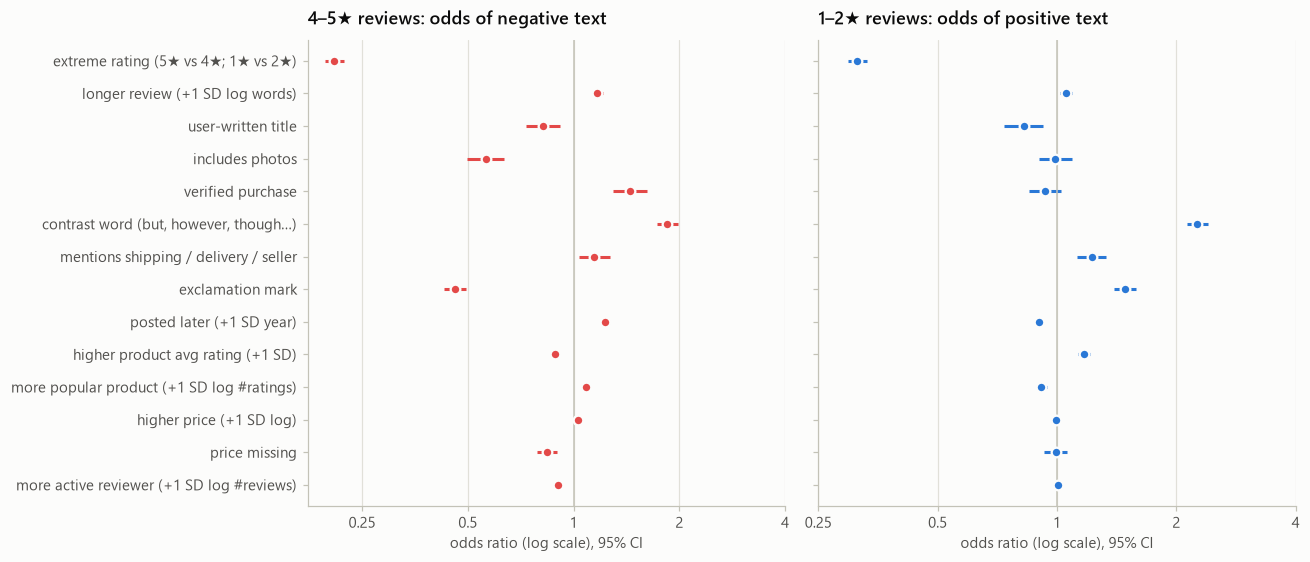

In [3]:
CONT = ["log_words", "year", "avg_rating", "log_rating_number", "log_price", "log_user_reviews"]
BIN = ["extreme", "has_title", "has_images", "verified_purchase", "has_contrast", "mentions_logistics",
       "has_exclaim", "price_missing"]
LABELS = {
    "extreme": "extreme rating (5★ vs 4★; 1★ vs 2★)",
    "z_log_words": "longer review (+1 SD log words)",
    "has_title": "user-written title",
    "has_images": "includes photos",
    "verified_purchase": "verified purchase",
    "has_contrast": "contrast word (but, however, though…)",
    "mentions_logistics": "mentions shipping / delivery / seller",
    "has_exclaim": "exclamation mark",
    "z_year": "posted later (+1 SD year)",
    "z_avg_rating": "higher product avg rating (+1 SD)",
    "z_log_rating_number": "more popular product (+1 SD log #ratings)",
    "z_log_price": "higher price (+1 SD log)",
    "price_missing": "price missing",
    "z_log_user_reviews": "more active reviewer (+1 SD log #reviews)",
}


def design(g):
    d = g[["inconsistent"] + BIN + CONT].copy()
    for c in ["inconsistent"] + BIN:
        d[c] = d[c].astype(int)
    for c in CONT:
        d[f"z_{c}"] = (d[c] - d[c].mean()) / d[c].std()
    return d


formula = "inconsistent ~ " + " + ".join(BIN + [f"z_{c}" for c in CONT])
fits = {name: smf.logit(formula, design(g)).fit(disp=0) for name, g in GROUPS.items()}
ors = {name: ratio_table(f).reindex(list(LABELS)) for name, f in fits.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)
for ax, (name, t) in zip(axes, ors.items()):
    forest(ax, t, labels=[LABELS[i] for i in t.index], color=COLOR[name])
    ax.set_title(f"{'4–5★' if name == HIGH_NEG else '1–2★'} reviews: odds of {name.split(',')[0]}")
    ax.set_xlabel("odds ratio (log scale), 95% CI")
    ticks = [0.25, 0.5, 1, 2, 4]
    ax.set_xticks(ticks, [str(t) for t in ticks])
    ax.minorticks_off()
fig.tight_layout()
savefig(fig, "04_odds_ratios")

pd.concat({name: t.round(3) for name, t in ors.items()}, axis=1).set_axis(
    [LABELS[i] for i in ors[HIGH_NEG].index])

In [4]:
for name, f in fits.items():
    print(f"{name}: n = {int(f.nobs):,}, pseudo-R² = {f.prsquared:.3f}")

negative text, high stars: n = 495,043, pseudo-R² = 0.099


positive text, low stars: n = 143,489, pseudo-R² = 0.079


### Robustness: the high-precision flag

The working flag includes many mixed reviews (audited precision ≈41% for 4–5★ and ≈14% for 1–2★).
The models are refit with `inconsistent_confident` (RoBERTa P(opposite) ≥ 0.8), which has higher
precision. A predictor whose odds ratio holds up, or grows, under the stricter flag is more likely to
track genuine inconsistency than mixed reviews.

In [5]:
def odds_ratios(g, outcome):
    return ratio_table(smf.logit(formula, design(g.assign(inconsistent=g[outcome]))).fit(disp=0)).odds_ratio


robust = pd.DataFrame({(name, flag): (ors[name].odds_ratio if flag == "working"
                                      else odds_ratios(g, "inconsistent_confident"))
                       for name, g in GROUPS.items() for flag in ["working", "confident"]}).reindex(list(LABELS))
robust.index = [LABELS[i] for i in robust.index]
robust.round(2)

negative text, high stars            \
                                                            working confident   
extreme rating (5★ vs 4★; 1★ vs 2★)                            0.21      0.19   
longer review (+1 SD log words)                                1.17      1.02   
user-written title                                             0.82      1.21   
includes photos                                                0.56      0.59   
verified purchase                                              1.45      1.46   
contrast word (but, however, though…)                          1.85      1.44   
mentions shipping / delivery / seller                          1.14      1.55   
exclamation mark                                               0.46      0.46   
posted later (+1 SD year)                                      1.23      1.41   
higher product avg rating (+1 SD)                              0.88      0.81   
more popular product (+1 SD log #ratings)                      1.08      1.14   
higher price (+1 SD log)                                       1.03      1.04   
price missing                                                  0.84      0.89   
more active reviewer (+1 SD log #reviews)                      0.90      0.90   

                                          positive text, low stars            
                                                           working confident  
extreme rating (5★ vs 4★; 1★ vs 2★)                           0.31      0.31  
longer review (+1 SD log words)                               1.05      0.87  
user-written title                                            0.82      0.98  
includes photos                                               0.99      1.03  
verified purchase                                             0.93      0.80  
contrast word (but, however, though…)                         2.26      1.98  
mentions shipping / delivery / seller                         1.22      1.32  
exclamation mark                                              1.48      2.08  
posted later (+1 SD year)                                     0.90      0.87  
higher product avg rating (+1 SD)                             1.17      1.14  
more popular product (+1 SD log #ratings)                     0.91      0.92  
higher price (+1 SD log)                                      0.99      1.00  
price missing                                                 0.99      0.91  
more active reviewer (+1 SD log #reviews)                     1.00      1.00

## Gradient boosting: how predictable is inconsistency, and from what?

The model uses the same features in unstandardised form. Importance is the drop in held-out AUC when
a feature is shuffled.

{'negative text, high stars': 0.792, 'positive text, low stars': 0.732}


,"negative text, high stars","positive text, low stars"
extreme,0.1005,0.1045
has_contrast,0.0363,0.0583
log_words,0.0324,0.0218
has_exclaim,0.0300,0.0018
year,0.0086,0.0054
log_rating_number,0.0083,0.0010
avg_rating,0.0074,0.0089
has_images,0.0040,-0.0000
log_user_reviews,0.0025,-0.0002
log_price,0.0018,-0.0008


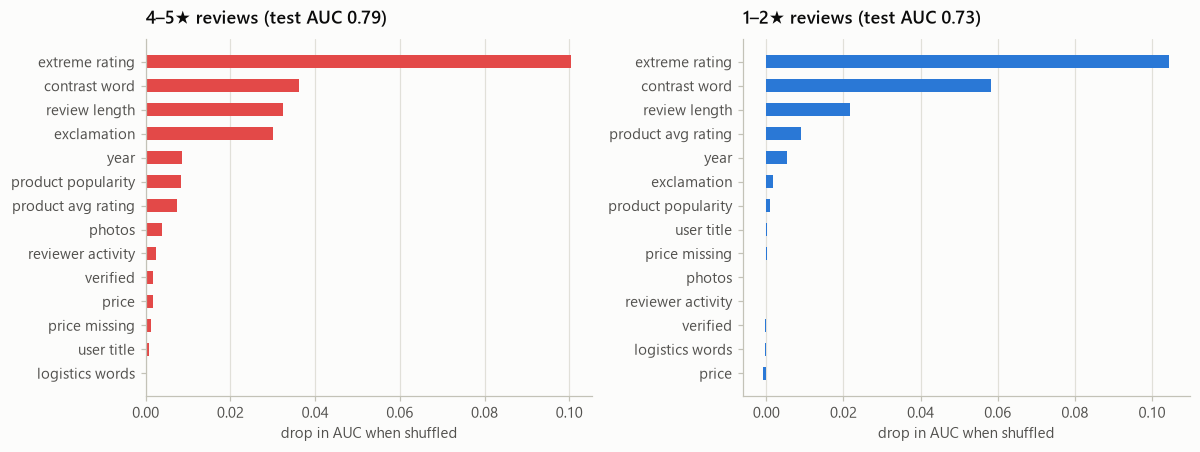

In [6]:
FEATURES = BIN + CONT
importances, aucs = {}, {}
for name, g in GROUPS.items():
    X = g[FEATURES].astype(float)
    y = g.inconsistent.astype(int)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
    model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, random_state=0).fit(X_tr, y_tr)
    aucs[name] = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    sub = X_te.sample(min(len(X_te), 40000), random_state=0)
    pi = permutation_importance(model, sub, y_te.loc[sub.index], scoring="roc_auc", n_repeats=5,
                                random_state=0)
    importances[name] = pd.Series(pi.importances_mean, index=FEATURES).sort_values()
print({k: round(v, 3) for k, v in aucs.items()})

names = {"log_words": "review length", "year": "year", "avg_rating": "product avg rating",
         "log_rating_number": "product popularity", "log_price": "price", "log_user_reviews": "reviewer activity",
         "extreme": "extreme rating", "has_title": "user title", "has_images": "photos",
         "verified_purchase": "verified", "has_contrast": "contrast word", "mentions_logistics": "logistics words",
         "has_exclaim": "exclamation", "price_missing": "price missing"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (name, imp) in zip(axes, importances.items()):
    ax.barh([names[i] for i in imp.index], imp.to_numpy(), height=0.55, color=COLOR[name])
    ax.set_title(f"{'4–5★' if name == HIGH_NEG else '1–2★'} reviews (test AUC {aucs[name]:.2f})")
    ax.set_xlabel("drop in AUC when shuffled")
    ax.grid(axis="y", visible=False)
fig.tight_layout()
savefig(fig, "04_permutation_importance")
pd.DataFrame(importances).round(4).sort_values(HIGH_NEG, ascending=False)

## What inconsistent reviews talk about

The tables give terms that are over-represented in inconsistent versus consistent reviews of the same
star group. The measure is the log-odds ratio with an informative Dirichlet prior (Monroe, Colaresi &
Quinn, 2008), and **z > 0 means more typical of inconsistent reviews**. Consistent reviews are
subsampled to 100,000 per group.

In [7]:
def distinctive_terms(a, b, n=20):
    vec = CountVectorizer(ngram_range=(1, 2), min_df=25, token_pattern=r"(?u)\b[a-z][a-z']+\b")
    X = vec.fit_transform(pd.concat([a, b]))
    ya = np.asarray(X[:len(a)].sum(axis=0)).ravel().astype(float)
    yb = np.asarray(X[len(a):].sum(axis=0)).ravel().astype(float)
    prior = 0.01 * (ya + yb) + 0.01
    a0, na, nb = prior.sum(), ya.sum(), yb.sum()
    delta = (np.log((ya + prior) / (na + a0 - ya - prior)) - np.log((yb + prior) / (nb + a0 - yb - prior)))
    z = delta / np.sqrt(1 / (ya + prior) + 1 / (yb + prior))
    t = pd.DataFrame({"term": vec.get_feature_names_out(), "z": z,
                      "per 10k words, inconsistent": 1e4 * ya / na, "per 10k words, consistent": 1e4 * yb / nb})
    return t.nlargest(n, "z").round(2).reset_index(drop=True)


terms = {}
for name, g in GROUPS.items():
    inc = g.loc[g.inconsistent, "full_text"]
    con = g.loc[~g.inconsistent, "full_text"].sample(100_000, random_state=0)
    terms[name] = distinctive_terms(inc, con)
    print(f"\n=== {name}: most distinctive of inconsistent reviews ===")
    display(terms[name])


=== negative text, high stars: most distinctive of inconsistent reviews ===


,term,z,"per 10k words, inconsistent","per 10k words, consistent"
0,not,52.63,114.60,39.32
1,but,35.54,113.78,55.81
2,bad,33.79,18.19,2.86
3,disappointed,31.92,11.46,1.07
4,broken,28.26,8.37,0.67
5,horrible,23.90,5.20,0.25
6,hate,21.95,5.73,0.59
7,was,21.55,72.70,42.43
8,wrong,21.34,6.30,0.83
9,hard,21.12,14.70,4.36



=== positive text, low stars: most distinctive of inconsistent reviews ===


,term,z,"per 10k words, inconsistent","per 10k words, consistent"
0,great,51.45,40.40,9.29
1,love,46.12,24.59,4.22
2,loved,30.91,9.81,1.43
3,nice,30.38,19.28,5.69
4,love the,27.93,8.68,1.42
5,beautiful,24.73,7.83,1.51
6,however,23.12,13.33,4.42
7,cute,22.63,10.30,2.95
8,but,21.81,90.89,62.39
9,amazing,21.77,4.72,0.66
